Control Conversion Rate: 12.0 %
Variant Conversion Rate: 15.0 %
Lift: 25.0 %
Z Statistic: -1.963
P Value: 0.0496
95% Confidence Interval:
0.0001 to 0.0599

Recommendation: Implement the new feature.


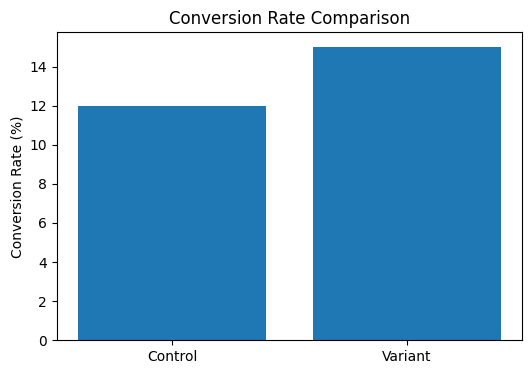

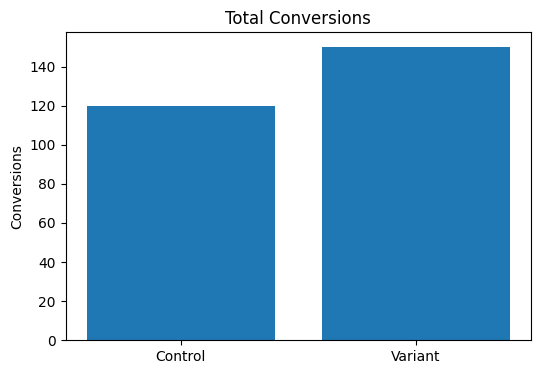

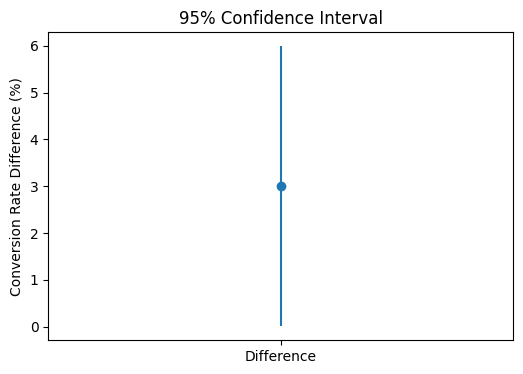

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

# ---------------------------
# Sample A/B Test Data
# ---------------------------
control_visitors = 1000
control_conversions = 120

variant_visitors = 1000
variant_conversions = 150

# ---------------------------
# Conversion Rates
# ---------------------------
control_rate = control_conversions / control_visitors * 100
variant_rate = variant_conversions / variant_visitors * 100

print("Control Conversion Rate:", round(control_rate, 2), "%")
print("Variant Conversion Rate:", round(variant_rate, 2), "%")

# ---------------------------
# Lift Calculation
# ---------------------------
lift = ((variant_rate - control_rate) / control_rate) * 100
print("Lift:", round(lift, 2), "%")

# ---------------------------
# Z-Test
# ---------------------------
conversions = np.array([control_conversions, variant_conversions])
visitors = np.array([control_visitors, variant_visitors])

z_stat, p_value = proportions_ztest(conversions, visitors)

print("Z Statistic:", round(z_stat, 4))
print("P Value:", round(p_value, 4))

# ---------------------------
# Confidence Interval
# ---------------------------
ci_low, ci_high = confint_proportions_2indep(
    count1=variant_conversions,
    nobs1=variant_visitors,
    count2=control_conversions,
    nobs2=control_visitors,
    method='wald'
)

print("95% Confidence Interval:")
print(round(ci_low, 4), "to", round(ci_high, 4))

# ---------------------------
# Decision
# ---------------------------
if p_value <= 0.05:
    print("\nRecommendation: Implement the new feature.")
else:
    print("\nRecommendation: Keep the current version.")

# ---------------------------
# Visualization 1
# Conversion Rate Comparison
# ---------------------------
groups = ['Control', 'Variant']
rates = [control_rate, variant_rate]

plt.figure(figsize=(6,4))
plt.bar(groups, rates)
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate Comparison")
plt.show()

# ---------------------------
# Visualization 2
# Conversions Comparison
# ---------------------------
plt.figure(figsize=(6,4))
plt.bar(groups,
        [control_conversions, variant_conversions])
plt.ylabel("Conversions")
plt.title("Total Conversions")
plt.show()

# ---------------------------
# Visualization 3
# Confidence Interval
# ---------------------------
difference = variant_rate - control_rate

plt.figure(figsize=(6,4))
plt.errorbar(
    x=["Difference"],
    y=[difference],
    yerr=[[difference - ci_low*100],
          [ci_high*100 - difference]],
    fmt='o'
)
plt.title("95% Confidence Interval")
plt.ylabel("Conversion Rate Difference (%)")
plt.show()